# 🔍 Training and Evaluation

## ⚙️ Library Imports and Setup

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from collections import Counter

from xgboost import XGBClassifier
import numpy as np


## 💾 Load Cleaned Dataset

In [91]:
df = pd.read_parquet('../data/cleaned_data.parquet')

## 🔍 Count of Pass vs Fail in the Dataset

C:\Users\PC-B4C-SYRINE\AppData\Local\Temp\ipykernel_14756\3097840657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_result', palette={'0': 'green', '1': 'red'})


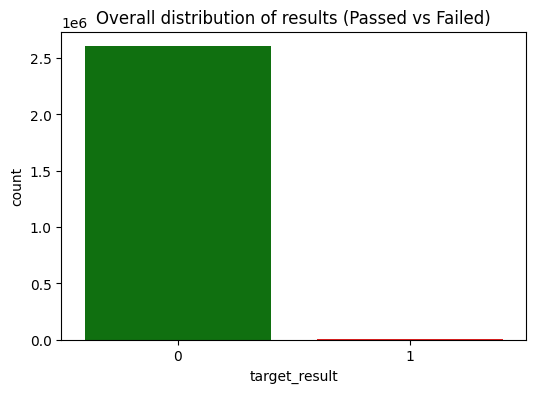

In [92]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target_result', palette={'0': 'green', '1': 'red'})
plt.title("Overall distribution of results (Passed vs Failed)")
plt.show()

## 📊 Boxplot Analysis of Component Positions

C:\Users\PC-B4C-SYRINE\AppData\Local\Temp\ipykernel_14756\1182568537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='target_result', y=col,
C:\Users\PC-B4C-SYRINE\AppData\Local\Temp\ipykernel_14756\1182568537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='target_result', y=col,
C:\Users\PC-B4C-SYRINE\AppData\Local\Temp\ipykernel_14756\1182568537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='target_result', y=col,
C:\Users\PC-B4C-SYRINE\AppData\Local\Temp\ipykernel_14756\118

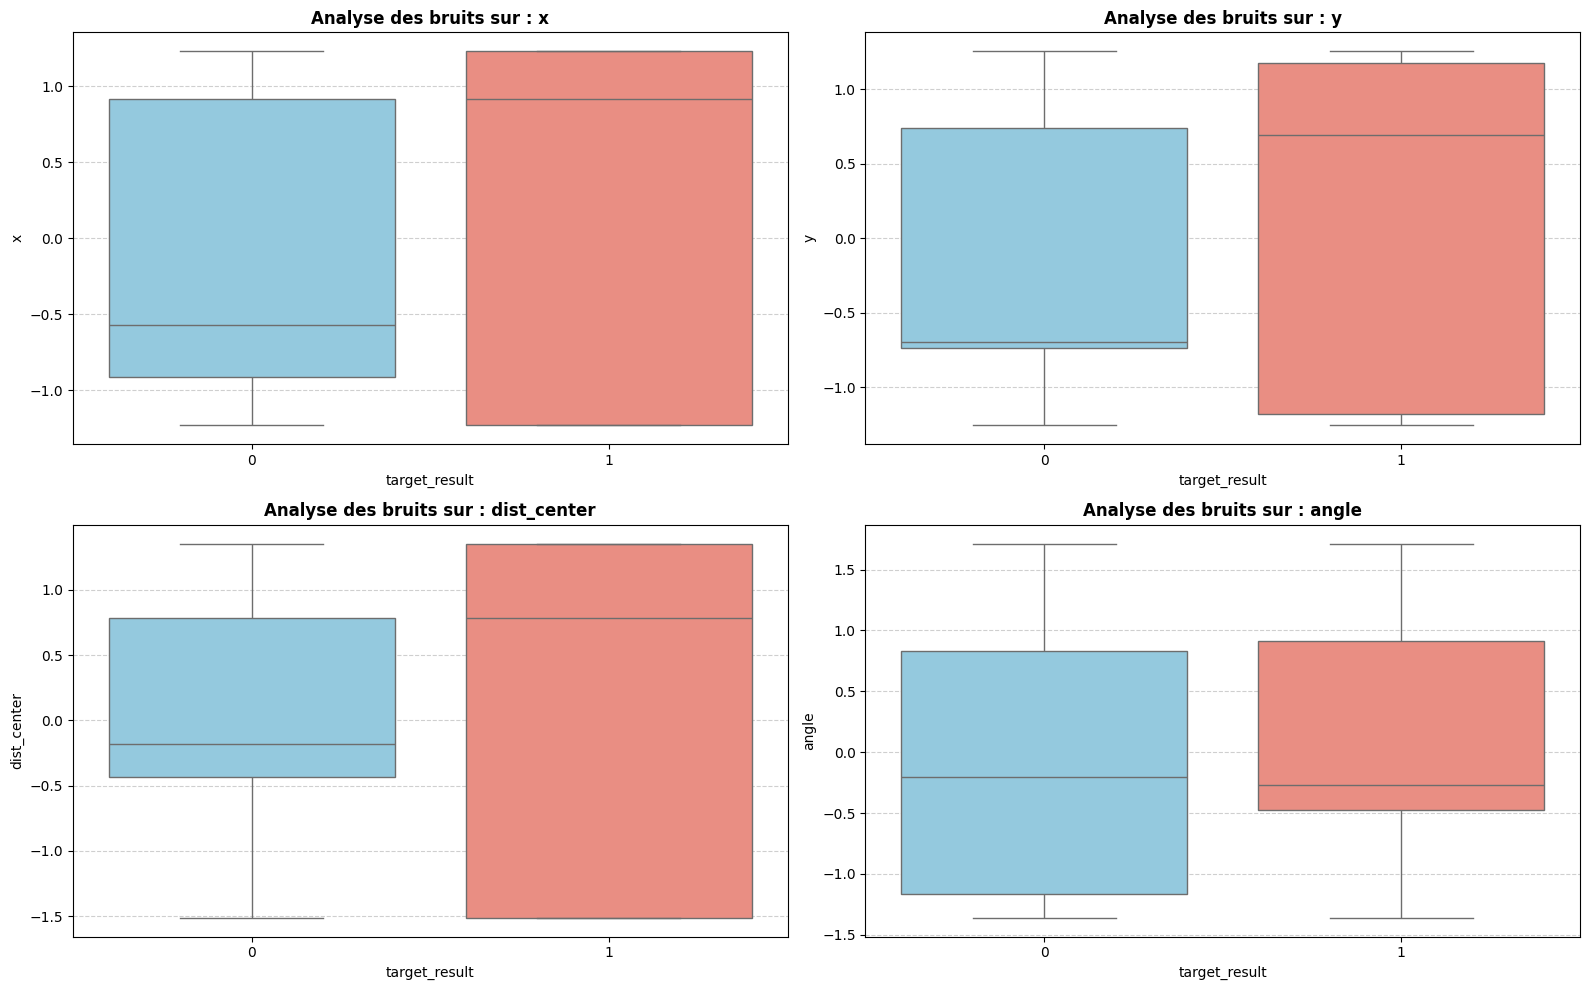

In [93]:
df_plot = df.copy()
df_plot['target_result'] = df_plot['target_result'].astype(str)

# Variables à analyser pour détecter les anomalies de position
features_to_plot = ['x', 'y', 'dist_center', 'angle']

plt.figure(figsize=(16, 10))

for i, col in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    # flierprops permet de mettre en évidence les "bruits" (points isolés)
    sns.boxplot(data=df_plot, x='target_result', y=col, 
                palette={'0': 'skyblue', '1': 'salmon'},
                flierprops={"marker": "x", "markerfacecolor": "black", "markersize": 3})
    
    plt.title(f'Analyse des bruits sur : {col}', fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 🔍 Splitting Dataset into Training and Testing Sets

In [94]:
X = df.drop(columns=['target_result', 'barcode', 'defect_code'])
y = df['target_result']

# 2. Separation: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {X_train.shape[0]} components.")
print(f"Test on {X_test.shape[0]} components.")

Training on 2090968 components.
Test on 522742 components.


## 🔍 Verify Class Balance in Train and Test Sets

In [95]:
# Calculate percentages for the Training set
train_dist = y_train.value_counts(normalize=True) * 100
# Calculate percentages for the Test set
test_dist = y_test.value_counts(normalize=True) * 100

# Create a clean summary table
# 0 usually represents 'Pass' and 1 represents 'Fail'
distribution_report = pd.DataFrame({
    'Train Set (%)': train_dist,
    'Test Set (%)': test_dist
}).rename(index={0: 'Pass', 1: 'Fail'})
print("✅ Class distribution in Train and Test sets:")
display(distribution_report)


✅ Class distribution in Train and Test sets:


,Train Set (%),Test Set (%)
target_result,,
Pass,99.668096,99.668096
Fail,0.331904,0.331904


## 📊 Visualizing Class Balance

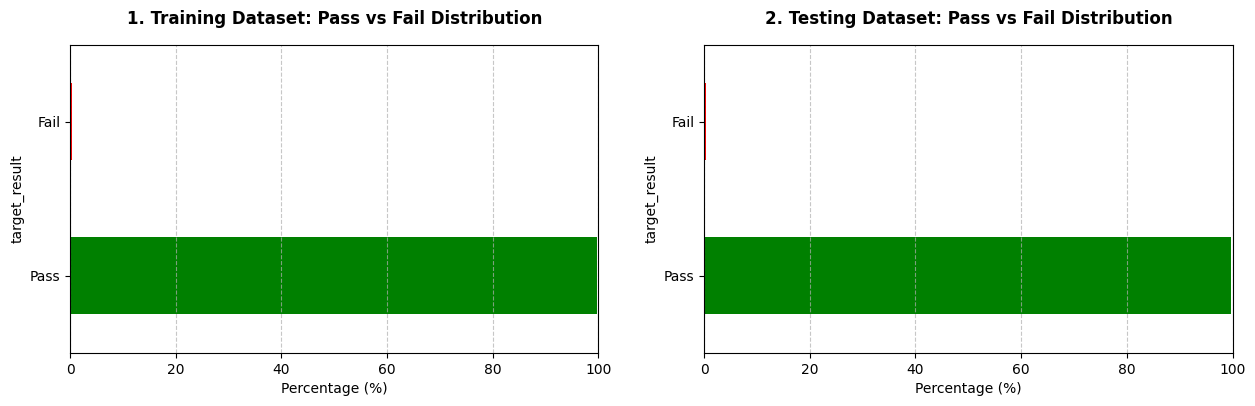

Confirmation of proportions (should be nearly identical):
               Train Set (%)  Test Set (%)
target_result                             
Pass               99.668096     99.668096
Fail                0.331904      0.331904


In [96]:
plot_data = distribution_report.copy()
mapping = {'0': 'Pass', '1': 'Failed', '0.0': 'Pass', '1.0': 'Failed'}
plot_data.index = plot_data.index.to_series().replace(mapping)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

# TOP PLOT: Training Set
plot_data['Train Set (%)'].plot(kind='barh', color=['green', 'red'], ax=ax1)
ax1.set_title("1. Training Dataset: Pass vs Fail Distribution", fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Percentage (%)")
ax1.set_xlim(0, 100) # Set limit to 100% for better perspective
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# BOTTOM PLOT: Test Set
plot_data['Test Set (%)'].plot(kind='barh', color=['green', 'red'], ax=ax2)
ax2.set_title("2. Testing Dataset: Pass vs Fail Distribution", fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Percentage (%)")
ax2.set_xlim(0, 100)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplots_adjust(hspace=1) 

plt.show()

# --- FINAL NUMERIC CHECK ---
print("Confirmation of proportions (should be nearly identical):")
print(plot_data)

## 🌲 Random Forest Model Training and Evaluation

In [97]:
# Creation of the model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
# Launch of learning
model.fit(X_train, y_train)

# Prediction on test data
y_pred = model.predict(X_test)

print("--- Performance report ---")
print(classification_report(y_test, y_pred))

--- Performance report ---
              precision    recall  f1-score   support

           0       1.00      0.71      0.83    521007
           1       0.01      0.77      0.02      1735

    accuracy                           0.71    522742
   macro avg       0.50      0.74      0.42    522742
weighted avg       1.00      0.71      0.83    522742



## 🧩 Confusion Matrix Visualization

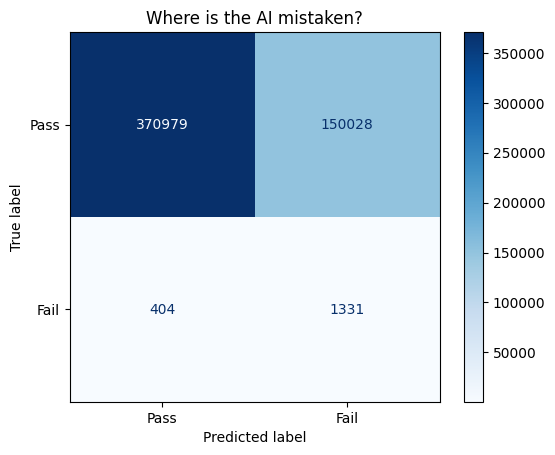

In [98]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
disp.plot(cmap='Blues')
plt.title("Where is the AI mistaken?")
plt.show()

## 🎯 Precision-Recall Curve

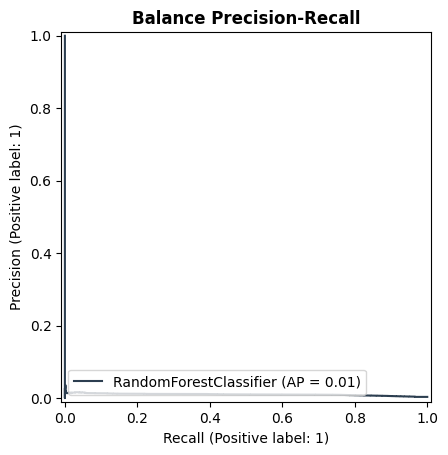

In [99]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, color='#2c3e50')
plt.title("Balance Precision-Recall", fontweight='bold')
plt.show()

## 🔍 Train Random Forest with Optimized Parameters and Balanced Classes

In [100]:
model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("--- Performance report ---")
print(classification_report(y_test, y_pred))

--- Performance report ---
              precision    recall  f1-score   support

           0       1.00      0.72      0.84    521007
           1       0.01      0.76      0.02      1735

    accuracy                           0.72    522742
   macro avg       0.50      0.74      0.43    522742
weighted avg       1.00      0.72      0.84    522742



## ⚙️ Model Interpretation (Random Forest Feature Importance Analysis)

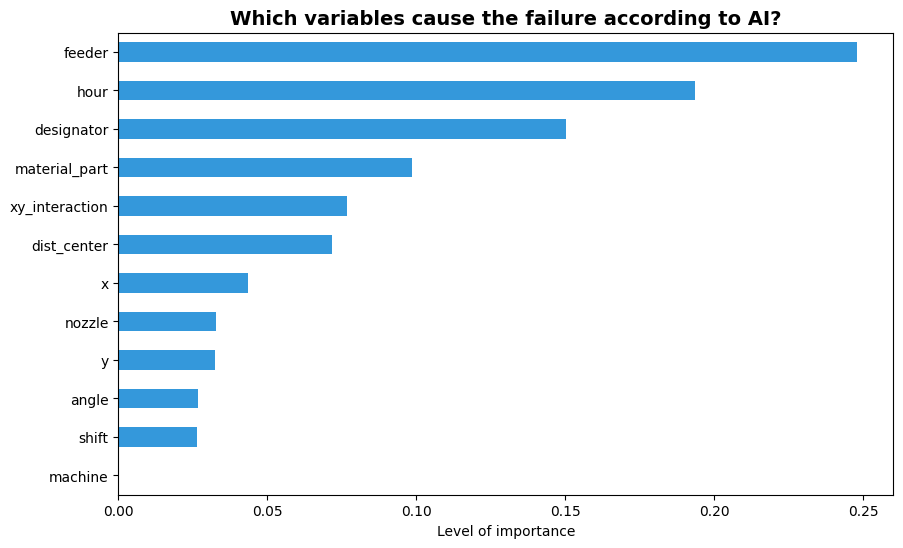

In [101]:
# Extraction of importance
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)

# Display of the 15 most influential variables
plt.figure(figsize=(10, 6))
feat_importances.nlargest(15).plot(kind='barh', color='#3498db')
plt.title("Which variables cause the failure according to AI?", fontsize=14, fontweight='bold')
plt.xlabel("Level of importance")
plt.gca().invert_yaxis() # To have the most important at the top

plt.show()

## 🔍 Train Random Forest on Selected Features with Optimized Parameters

In [102]:
# --- 1. DATA CLEANING (We define X_clean here) ---
# Replace 'df' with the name of your main DataFrame if necessary
# We keep the variables that have weight and remove the 'noise' (machine, shift, nozzle)
# --- 1. SELECT IMPORTANT FEATURES ---
# Keep only the columns that were found important from feature importance analysis
important_cols = ['feeder', 'hour', 'material_part', 'designator', 'xy_interaction', 'nozzle']

# Create a new DataFrame with only these columns
X_clean = df[important_cols].copy()
y = df['target_result']  # Target variable: 0 = Pass, 1 = Fail

print(f"✅ Selected features: {X_clean.columns.tolist()}")
print(f"Dataset shape: X={X_clean.shape}, y={y.shape}")

# --- 2. ENCODING CATEGORICAL FEATURE ---
# Random Forest needs numerical input. Convert 'material_part' if it's still text
if X_clean['material_part'].dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    X_clean['material_part'] = le.fit_transform(X_clean['material_part'].astype(str))
    print("✅ 'material_part' encoded as integers.")

# --- 3. SPLIT INTO TRAIN AND TEST SETS ---
# Use stratification to keep the same proportion of Fail/Pass in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)
print(f"✅ Split done: Train={X_train.shape[0]}, Test={X_test.shape[0]}")

# --- 4. TRAIN OPTIMIZED RANDOM FOREST MODEL ---
model = RandomForestClassifier(
    n_estimators=200,       # Number of trees
    max_depth=12,           # Avoid overfitting by limiting depth
    min_samples_leaf=10,    # Ensure stability
    class_weight='balanced',# Handle class imbalance
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

print("🚀 Training Random Forest...")
model.fit(X_train, y_train)
print("✅ Model trained.")

# --- 5. EVALUATE MODEL PERFORMANCE ---
y_pred = model.predict(X_test)

print("--- Performance Report ---")
print(classification_report(y_test, y_pred))

✅ Selected features: ['feeder', 'hour', 'material_part', 'designator', 'xy_interaction', 'nozzle']
Dataset shape: X=(2613710, 6), y=(2613710,)
✅ Split done: Train=2090968, Test=522742
🚀 Training Random Forest...
✅ Model trained.
--- Performance Report ---
              precision    recall  f1-score   support

           0       1.00      0.73      0.84    521007
           1       0.01      0.74      0.02      1735

    accuracy                           0.73    522742
   macro avg       0.50      0.74      0.43    522742
weighted avg       1.00      0.73      0.84    522742



## 💾 Save Trained XGBoost Model

In [103]:
# Define the folder name
model_dir = './models'

# Create the directory if it doesn't exist
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Directory '{model_dir}' created successfully.")

# --- MODEL EXPORT ---
# Define the full path including the folder
model_path = os.path.join(model_dir, 'maintenance_model.pkl')

# Save the trained XGBoost model
joblib.dump(model, model_path)

print(f"Model successfully saved in: {model_path}")

Model successfully saved in: ./models\maintenance_model.pkl


## 🔍 Handling Class Imbalance Using SMOTE and Retraining Random Forest

In [104]:
print(f"Before SMOTE : {Counter(y_train)}")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"After SMOTE : {Counter(y_train_res)}")

model_balanced = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1
)

model_balanced.fit(X_train_res, y_train_res)

y_pred_new = model_balanced.predict(X_test)
print("--- Report after Re-balancing SMOTE ---")
print(classification_report(y_test, y_pred_new))

Before SMOTE : Counter({0: 2084028, 1: 6940})
After SMOTE : Counter({0: 2084028, 1: 2084028})


MemoryError: Unable to allocate 31.8 MiB for an array with shape (4168056,) and data type float64

## 🔍 Handle Class Imbalance with SMOTETomek and Optimize Threshold for Fail Detection

Distribution after SMOTETomek: Counter({0: 2084026, 1: 2084026})
 n--- Report with optimized threshold ---
              precision    recall  f1-score   support

           0       1.00      0.66      0.79    521007
           1       0.01      0.80      0.02      1735

    accuracy                           0.66    522742
   macro avg       0.50      0.73      0.40    522742
weighted avg       1.00      0.66      0.79    522742



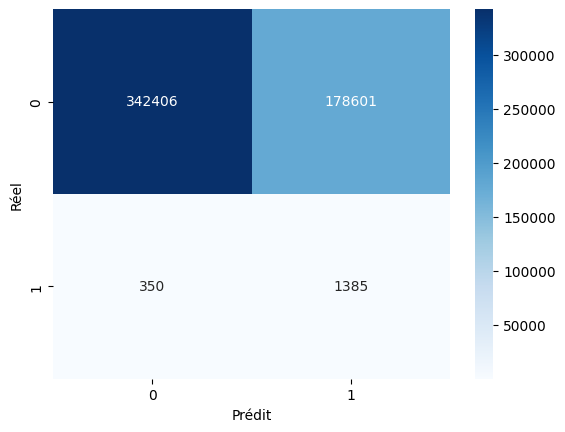

In [ ]:
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)

print(f"Distribution after SMOTETomek: {Counter(y_resampled)}")

# 2. Model with class weighting
model = RandomForestClassifier(
    class_weight='balanced_subsample',
    n_estimators=150,
    max_depth=12,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

# 3. Training
model.fit(X_resampled, y_resampled)

# 4. Prediction with probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Threshold optimization
threshold = 0.4  # Adjust to your needs
y_pred_optimized = (y_proba >= threshold).astype(int)

# 6. Evaluation
print(" n--- Report with optimized threshold ---")
print(classification_report(y_test, y_pred_optimized))

# 7. Confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

In [ ]:
display(X_train)

,designator,nozzle,feeder,material_part,x,y,machine,hour,shift,dist_center,xy_interaction,angle
580083,3,2,0,1,1.232397,1.178570,0,1.537449,2,1.354492,1.738164,-0.474432
2322622,2,2,8,3,0.914287,1.258088,0,0.021677,1,1.111114,1.467910,-0.267908
2315840,1,2,6,2,-1.147720,0.694922,0,-0.584631,1,-0.435661,-0.796481,1.713543
316379,2,0,8,3,0.914287,1.258088,0,-0.887786,1,1.111114,1.467910,-0.267908
2091127,2,1,8,3,0.914287,1.258088,0,-1.494094,2,1.111114,1.467910,-0.267908
...,...,...,...,...,...,...,...,...,...,...,...,...
136494,3,1,0,1,-1.232530,-1.177259,0,-0.281477,1,-1.509873,-1.056169,0.916014
397719,0,0,9,2,0.571150,-0.737108,0,-0.129900,1,0.201710,-0.203134,-1.162891
2274666,3,1,0,1,1.232397,1.178570,0,-0.433054,1,1.354492,1.738164,-0.474432
2642460,2,1,8,3,-0.914487,-1.257138,0,0.021677,1,-1.327926,-0.972243,-0.196879


Distribution after SMOTETomek: Counter({0: 2084027, 1: 2084027})
Dynamic scale_pos_weight for XGBoost: 1.00
Training XGBoost...
Optimal threshold for Fail detection: 0.78
--- Classification Report with Optimized Threshold ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    521007
           1       0.01      0.21      0.02      1735

    accuracy                           0.94    522742
   macro avg       0.50      0.58      0.50    522742
weighted avg       0.99      0.94      0.97    522742



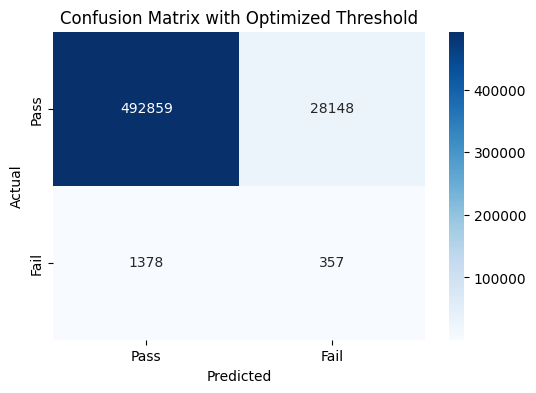

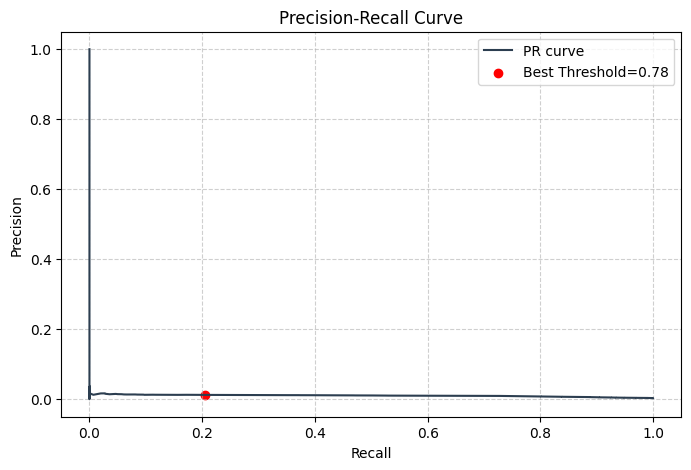

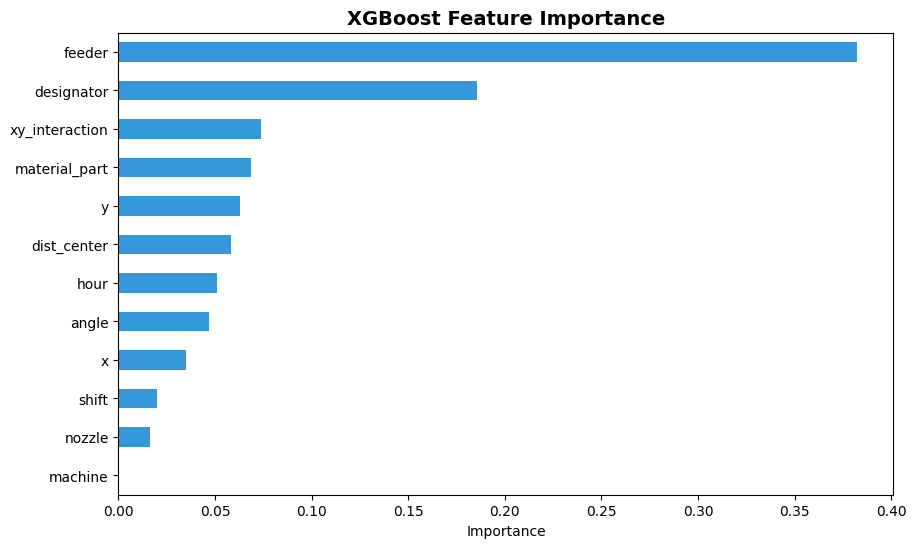

In [ ]:
# --- 1. Apply SMOTETomek on training data ---
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)

print(f"Distribution after SMOTETomek: {Counter(y_resampled)}")

# --- 2. Compute dynamic scale_pos_weight for XGBoost ---
count_pass = len(y_resampled[y_resampled == 0])
count_fail = len(y_resampled[y_resampled == 1])
dynamic_ratio = count_pass / count_fail
print(f"Dynamic scale_pos_weight for XGBoost: {dynamic_ratio:.2f}")

# --- 3. Train XGBoost ---

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    scale_pos_weight=dynamic_ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
model_xgb.fit(X_resampled, y_resampled)

# --- 4. Predict probabilities on test set ---
y_proba = model_xgb.predict_proba(X_test)[:, 1]

# --- 5. Find optimal threshold using Precision-Recall curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold for Fail detection: {best_threshold:.2f}")

# Apply optimized threshold
y_pred_opt = (y_proba >= best_threshold).astype(int)

# --- 6. Classification Report ---
print("--- Classification Report with Optimized Threshold ---")
print(classification_report(y_test, y_pred_opt))

# --- 7. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pass','Fail'], yticklabels=['Pass','Fail'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix with Optimized Threshold")
plt.show()

# --- 8. Precision-Recall Curve ---
plt.figure(figsize=(8,5))
plt.plot(recall, precision, color='#2c3e50', label='PR curve')
plt.scatter(recall[best_idx], precision[best_idx], color='red', label=f'Best Threshold={best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 9. Feature Importance ---

feat_importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10,6))
feat_importances.sort_values(ascending=True).plot(kind='barh', color='#3498db')
plt.title("XGBoost Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Importance")
plt.show()

## 🔍 Handle Class Imbalance Using XGBoost and Dynamic scale_pos_weight

In [ ]:
count_pass = len(y_train[y_train == 0])
count_fail = len(y_train[y_train == 1])
dynamic_ratio = count_pass / count_fail

print(f"Dataset Stats - Pass: {count_pass}, Fail: {count_fail}")
print(f"Calculated dynamic scale_pos_weight: {dynamic_ratio:.2f}")

# --- MODEL INITIALIZATION ---
# Using XGBoost with boosting trees to handle non-linear coordinate patterns
model_xgb = XGBClassifier(
    n_estimators=300,        # Number of boosting rounds
    learning_rate=0.05,      # Step size shrinkage to prevent overfitting
    max_depth=8,             # Max tree depth for complex feature interactions
    scale_pos_weight=dynamic_ratio,  # Key parameter to handle class imbalance
    subsample=0.8,           # Use 80% of data to train each tree (robustness)
    colsample_bytree=0.8,    # Fraction of features used for each tree
    random_state=42,
    n_jobs=-1                # Use all available CPU cores
)

print("Training XGBoost...")
model_xgb.fit(X_train, y_train)

# --- EVALUATION ---
y_pred_xgb = model_xgb.predict(X_test)
print("--- XGBoost Performance Report ---")
print(classification_report(y_test, y_pred_xgb))